# Does position change OB sniff-locking?

Scores come from `position_locking.py` (run `python position_locking.py --regions ob`). Each inhalation is a trial with a
latency profile of spikes, a nose position (3 x 7 arena bins) and a sniff-frequency quintile. Spike counts
`C[freq, pos, latency]` are compared against two models that let position change the unit **without** changing its
sniff-locking:

| model | position may change... | residual info = |
|---|---|---|
| separable `O * a[f,p] * b[f,l]` | overall rate (gain) | **interaction**: any change in the latency profile's shape (depth or timing) |
| affine `O * (c[f,p] + g[f,p] * b[f,l])` | rate *and* locking depth (baseline vs locked gain) | **timing**: change in *when* in the sniff it fires (latency shift / width) |

Both models let the latency profile depend on sniff frequency. Because the strata are coarse and latency changes
continuously with sniff duration, some frequency effect still leaks in wherever frequency differs by position (e.g.
fast sniffing at the ports). The null therefore swaps spike patterns between sniffs of nearly equal duration from the
same quarter of the session: every sniff keeps its position and duration, so the null has the same leak and slow
drift, and only the position <-> spike-timing link is broken. `*_frac` = shuffle-corrected bits / sniff-locking bits,
i.e. the fraction of the unit's locking that depends on position.

Validated on synthetic units over real sniffs (9003/x3 and 9008/x10): no effect, pure gain, and latency / width / gain
that depend continuously on sniff duration all give |z| < 1.5; a depth change gives interaction z ~ 43 with timing
z < 1; a 5 ms latency shift gives timing z ~ 6-9. (A circular-shift null scored the duration-dependent latency unit
at z = 37 on 9008/x10, which is why it was replaced.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import position_locking as pl
from scipy.ndimage import gaussian_filter1d

keys = ['mouse', 'session', 'region', 'cluster']
pos_lock = pd.read_csv(pl.OUT_FILE)
sniff_lock = pd.read_csv('E:/cbm-odor/sniff/sniff_locking.csv')
space = pd.read_csv('E:/cbm-odor/sniff/spatial_info.csv')
for d in (pos_lock, sniff_lock, space):
    d['mouse'] = d['mouse'].astype(str)
df = (pos_lock
      .merge(sniff_lock[keys + ['info_z', 'info_p', 'peak_latency_ms']], on=keys, how='left', validate='one_to_one')
      .merge(space[keys + ['ssi', 'p_empirical']], on=keys, how='left', validate='one_to_one'))
df = df[df['timing_z'].notna()]
df['sniff_locked'] = df['info_p'] < 0.05
df['place_tuned'] = df['p_empirical'] < 0.05
df['sig_interaction'] = df['interaction_p'] < 0.01
df['sig_timing'] = df['timing_p'] < 0.01
print(f"{len(df)} OB units scored, {df['sniff_locked'].sum()} sniff-locked")
display(df.groupby('sniff_locked')[['sig_interaction', 'sig_timing']].mean().rename(columns=lambda c: c + ' (frac)'))
# Calibration check: with a perfect null, median z ~ 0 and ~1% of units pass p < 0.01. Non-locked units can still
# have real position-dependent locking, so their pass rate is only an upper bound on the false-positive rate.
display(df.groupby('sniff_locked')[['interaction_z', 'timing_z']].median().rename(columns=lambda c: c + ' (median)'))

1927 OB units scored, 1635 sniff-locked


,sig_interaction (frac),sig_timing (frac)
sniff_locked,,
False,0.136986,0.078767
True,0.489297,0.358410


,interaction_z (median),timing_z (median)
sniff_locked,,
False,0.815082,0.683894
True,2.386394,1.707151


## Distributions

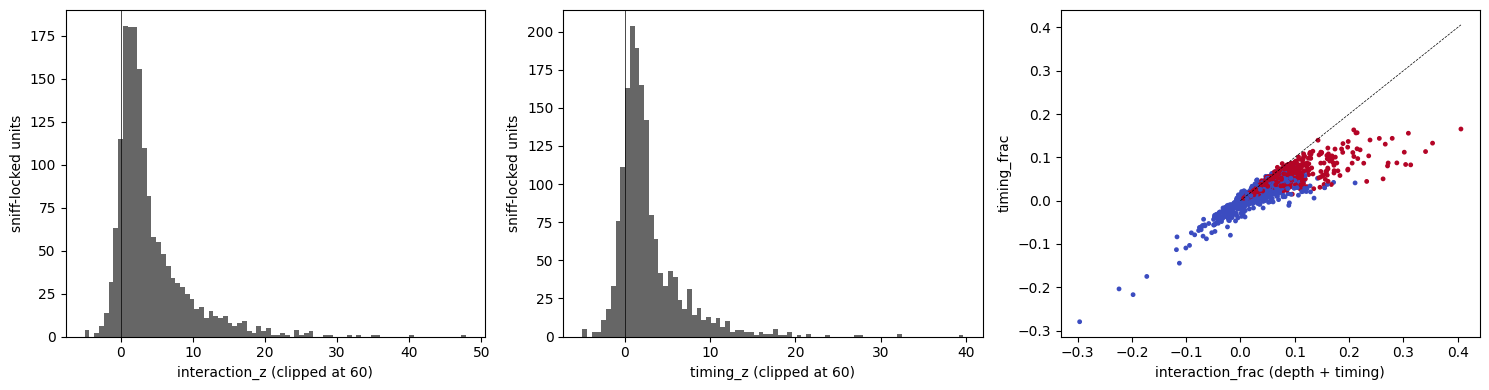

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
locked = df[df['sniff_locked']]
for ax, col in zip(axes[:2], ['interaction_z', 'timing_z']):
    ax.hist(np.clip(locked[col], -5, 60), bins=80, color='0.4')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel(col + ' (clipped at 60)')
    ax.set_ylabel('sniff-locked units')
ax = axes[2]
ax.scatter(locked['interaction_frac'], locked['timing_frac'], s=6, c=locked['sig_timing'], cmap='coolwarm')
ax.plot([0, locked['interaction_frac'].max()], [0, locked['interaction_frac'].max()], 'k--', lw=0.5)
ax.set_xlabel('interaction_frac (depth + timing)')
ax.set_ylabel('timing_frac')
plt.tight_layout()
plt.show()

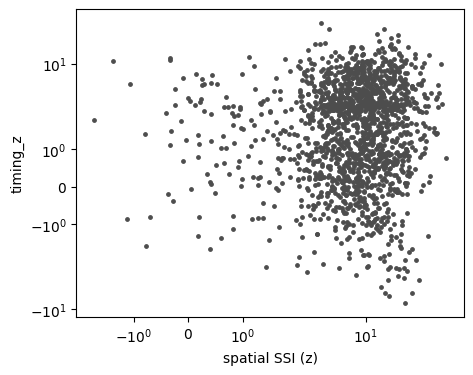

sig_timing,False,True,All
place_tuned,,,
False,92,33,125
True,957,553,1510
All,1049,586,1635


In [3]:
# Is position-dependent locking just place tuning? (rate effects are factored out, but they may co-occur)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(locked['ssi'], locked['timing_z'], s=6, c='0.3')
ax.set_xlabel('spatial SSI (z)')
ax.set_ylabel('timing_z')
ax.set_xscale('symlog'); ax.set_yscale('symlog')
plt.show()
display(pd.crosstab(locked['place_tuned'], locked['sig_timing'], margins=True))

## Top units: position changes *when* in the sniff they fire

In [4]:
cols = keys + ['group', 'n_spikes_used', 'info_z', 'ssi', 'lock_bits_per_spike',
               'interaction_z', 'interaction_frac', 'timing_z', 'timing_corrected', 'timing_frac']
# ranked by corrected bits/spike so weakly locked units with a large fraction don't dominate
top_timing = locked[locked['sig_timing'] & (locked['n_spikes_used'] >= 5000)].sort_values('timing_corrected', ascending=False)
display(top_timing[cols].head(25))

,mouse,session,region,cluster,group,n_spikes_used,info_z,ssi,lock_bits_per_spike,interaction_z,interaction_frac,timing_z,timing_corrected,timing_frac
838,9005,x4,ob,31,mua,12224,347.637991,22.018072,0.490211,14.641307,0.099619,13.781503,0.043095,0.087910
837,9005,x4,ob,29,mua,17985,463.034238,19.549966,0.478360,19.267519,0.095500,17.354209,0.040033,0.083689
618,9003,x8,ob,11,good,66163,1574.462316,3.490260,0.618129,39.977220,0.059167,39.694901,0.035271,0.057061
617,9003,x8,ob,10,mua,18395,351.691541,4.848954,0.508631,14.309365,0.066031,15.127217,0.034073,0.066989
1876,9009,x4,ob,6,mua,23696,297.596677,17.503972,0.460897,17.435100,0.072891,18.220722,0.033241,0.072123
1878,9009,x4,ob,8,mua,21109,383.662324,20.005728,0.483867,16.378816,0.068059,16.741060,0.032184,0.066514
833,9005,x4,ob,21,mua,21122,236.835991,18.297315,0.329730,17.046846,0.101797,16.244186,0.029600,0.089769
616,9003,x8,ob,9,mua,15090,256.321366,10.547694,0.384983,10.632259,0.075997,10.409626,0.027024,0.070196
1395,9007,t2,ob,21,mua,38468,719.289318,3.835493,0.682469,24.091658,0.043780,20.153870,0.024747,0.036261
1394,9007,t2,ob,20,mua,67972,921.202240,4.266691,0.620173,35.722955,0.045813,32.125080,0.023755,0.038303


## Unit viewer

Top row: rate vs latency for each position bin (rows, ordered along the arena's long axis), one panel per sniff-frequency
quintile, each row normalized to its max (smoothed over 1 latency bin; bins less than half-covered by the sniffs are blank). Bottom row: arena maps of latency shift (response centroid in the first 90 ms vs the other positions), rate, and locking depth
(1 - min/max of the latency profile), pooled over frequency.

In [5]:
def plot_unit(mouse, session, cluster, region='ob'):
    mouse = str(mouse)
    units, spike_times, clusters = pl.load_units(mouse, session, region)
    last = (int(spike_times[-1]) + 15) // 30
    sess = pl.Session(mouse, session, last_ms=last, n_shuffle=0)
    spikes = spike_times[clusters == cluster].astype(float) / 30
    C, O = sess.counts(*sess.unit(spikes)).astype(float), sess.O
    Cs, Os = gaussian_filter1d(C, 1, axis=-1), gaussian_filter1d(O, 1, axis=-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        rate = np.where(O >= 0.5 * O[..., :1], 1e3 * Cs / Os, np.nan)  # Hz, (F, P, L); drop partial bins
        rate_p = np.where(O.sum(0) >= 0.5 * O.sum(0)[:, :1], 1e3 * Cs.sum(0) / Os.sum(0), np.nan)
    lat = sess.lat_edges[:-1] + pl.LAT_BIN_MS / 2
    ix, iy = np.divmod(sess.pos_bins, sess.ny)
    order = np.lexsort((ix, iy))  # along the long (y) axis

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3 * pl.N_FREQ)
    for f in range(pl.N_FREQ):
        ax = fig.add_subplot(gs[0, 3 * f:3 * f + 3])
        r = rate[f][order]
        ax.imshow(r / np.nanmax(r, 1, keepdims=True), aspect='auto', cmap='viridis', vmin=0, vmax=1,
                  extent=[0, pl.WINDOW_MS, len(order), 0], interpolation='nearest')
        ax.set_yticks(np.arange(len(order)) + 0.5, [f'({ix[o]},{iy[o]})' for o in order], fontsize=6)
        lo, hi = sess.freq_edges[f], sess.freq_edges[f + 1]
        ax.set_title(f'{lo:.1f}-{hi:.1f} Hz sniffs')
        ax.set_xlabel('latency from inhalation (ms)')
    fig.axes[0].set_ylabel('position bin (x, y)')

    peak = np.full((sess.nx, sess.ny), np.nan)
    mean_rate, depth = peak.copy(), peak.copy()
    # latency centroid of the above-baseline response in the first 90 ms (covered at every sniff rate), relative to
    # the mean over positions within each frequency stratum, then averaged over strata weighted by spikes
    above = np.where(lat < 90, rate - np.nanmin(rate, -1, keepdims=True), np.nan)
    centroid = np.nansum(above * lat, -1) / np.nansum(above, -1)  # (F, P)
    shift = centroid - np.nanmean(centroid, 1, keepdims=True)
    w = C.sum(-1)
    peak[ix, iy] = np.nansum(shift * w, 0) / w.sum(0)
    mean_rate[ix, iy] = 1e3 * C.sum((0, 2)) / O.sum((0, 2))
    depth[ix, iy] = 1 - np.nanmin(rate_p, 1) / np.nanmax(rate_p, 1)
    lim = np.nanmax(np.abs(peak))
    for i, (m, title, cmap) in enumerate([(peak, 'latency shift vs other positions (ms)', 'coolwarm'),
                                          (mean_rate, 'rate in window (Hz)', 'magma'),
                                          (depth, 'locking depth', 'cividis')]):
        ax = fig.add_subplot(gs[1, i * pl.N_FREQ:(i + 1) * pl.N_FREQ])
        im = ax.imshow(m.T, cmap=cmap, **(dict(vmin=-lim, vmax=lim) if i == 0 else {}), extent=[*pl.ARENA_X_RANGE_PX, pl.ARENA_Y_RANGE_PX[1], pl.ARENA_Y_RANGE_PX[0]])
        fig.colorbar(im, ax=ax, label=title)
        ax.set_title(title)
    row = df[(df['mouse'] == mouse) & (df['session'] == session) & (df['cluster'] == cluster)]
    stats = '' if row.empty else (f"  |  timing z={row['timing_z'].iat[0]:.1f}, frac={row['timing_frac'].iat[0]:.3f}"
                                  f"  |  interaction z={row['interaction_z'].iat[0]:.1f}")
    fig.suptitle(f'{mouse} {session} {region} cl {cluster}{stats}')
    plt.tight_layout()
    plt.show()

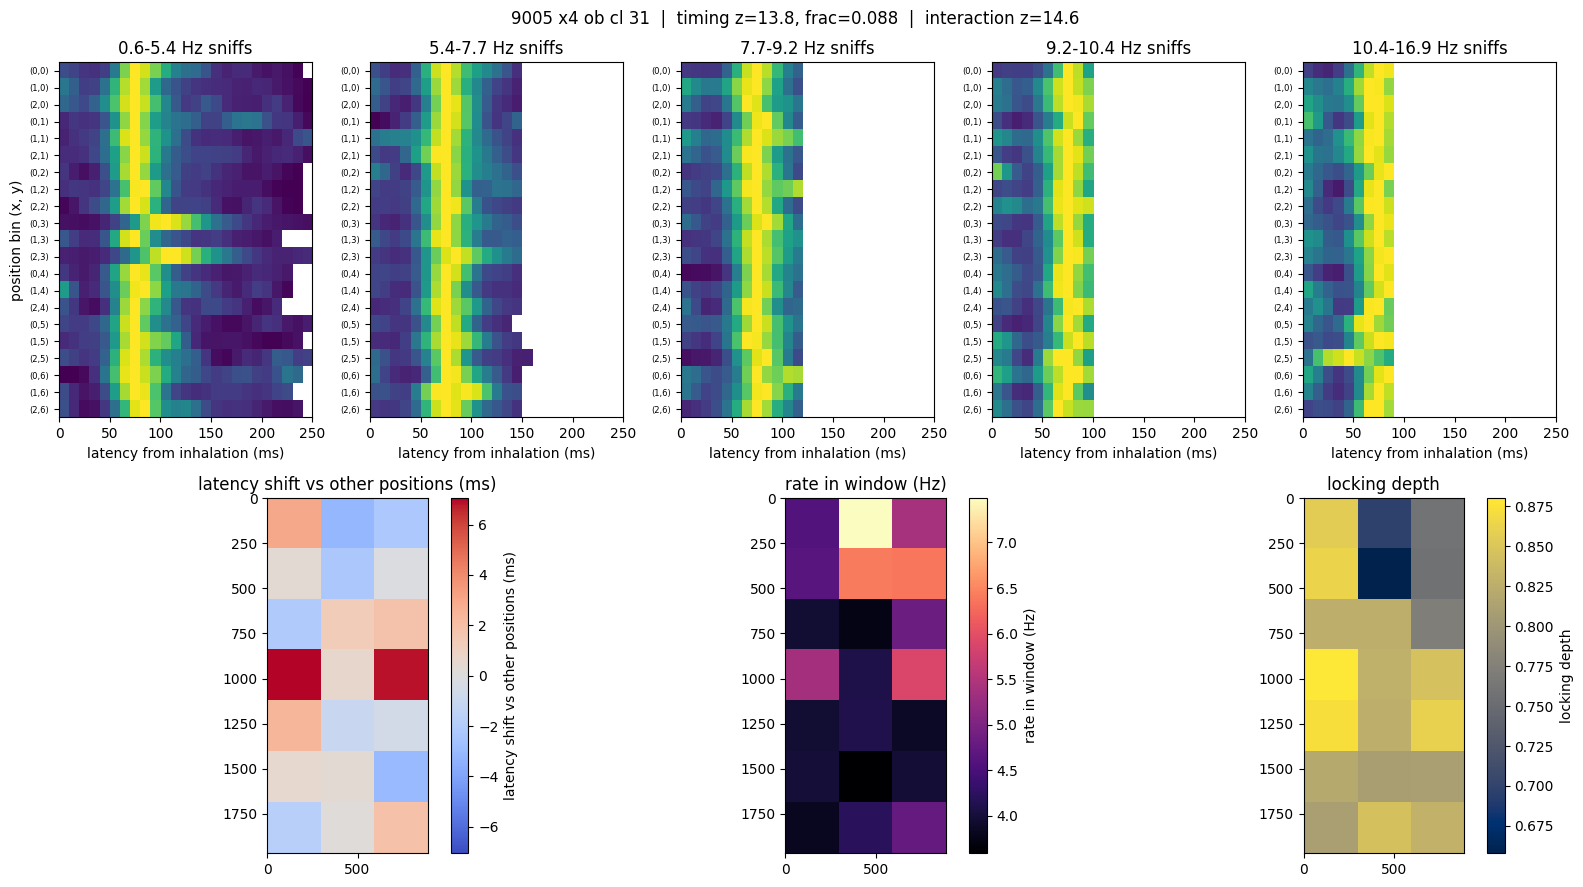

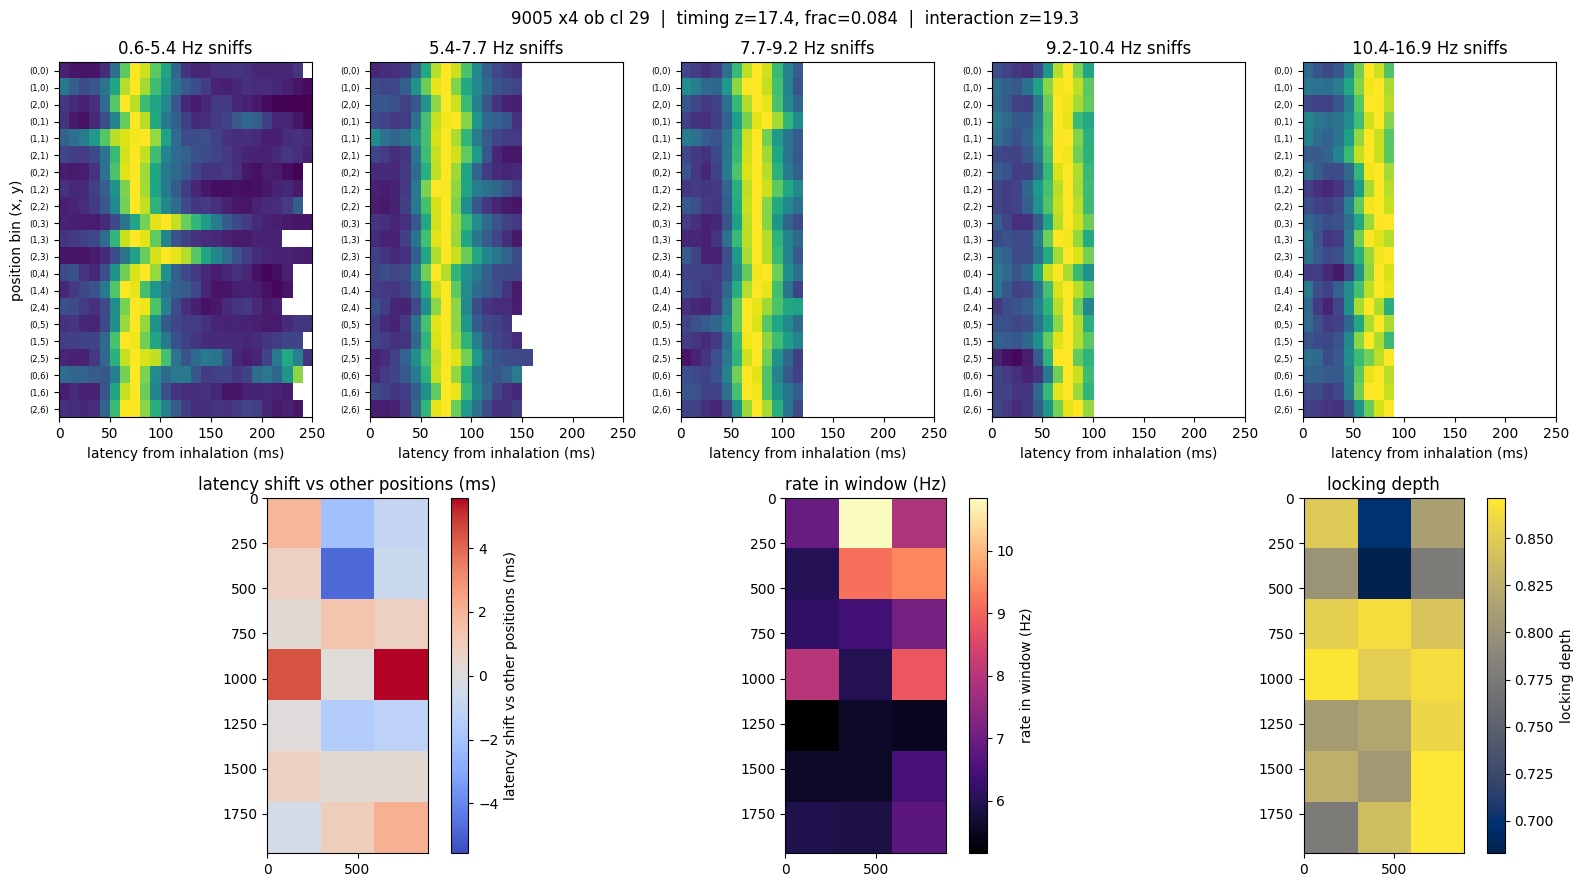

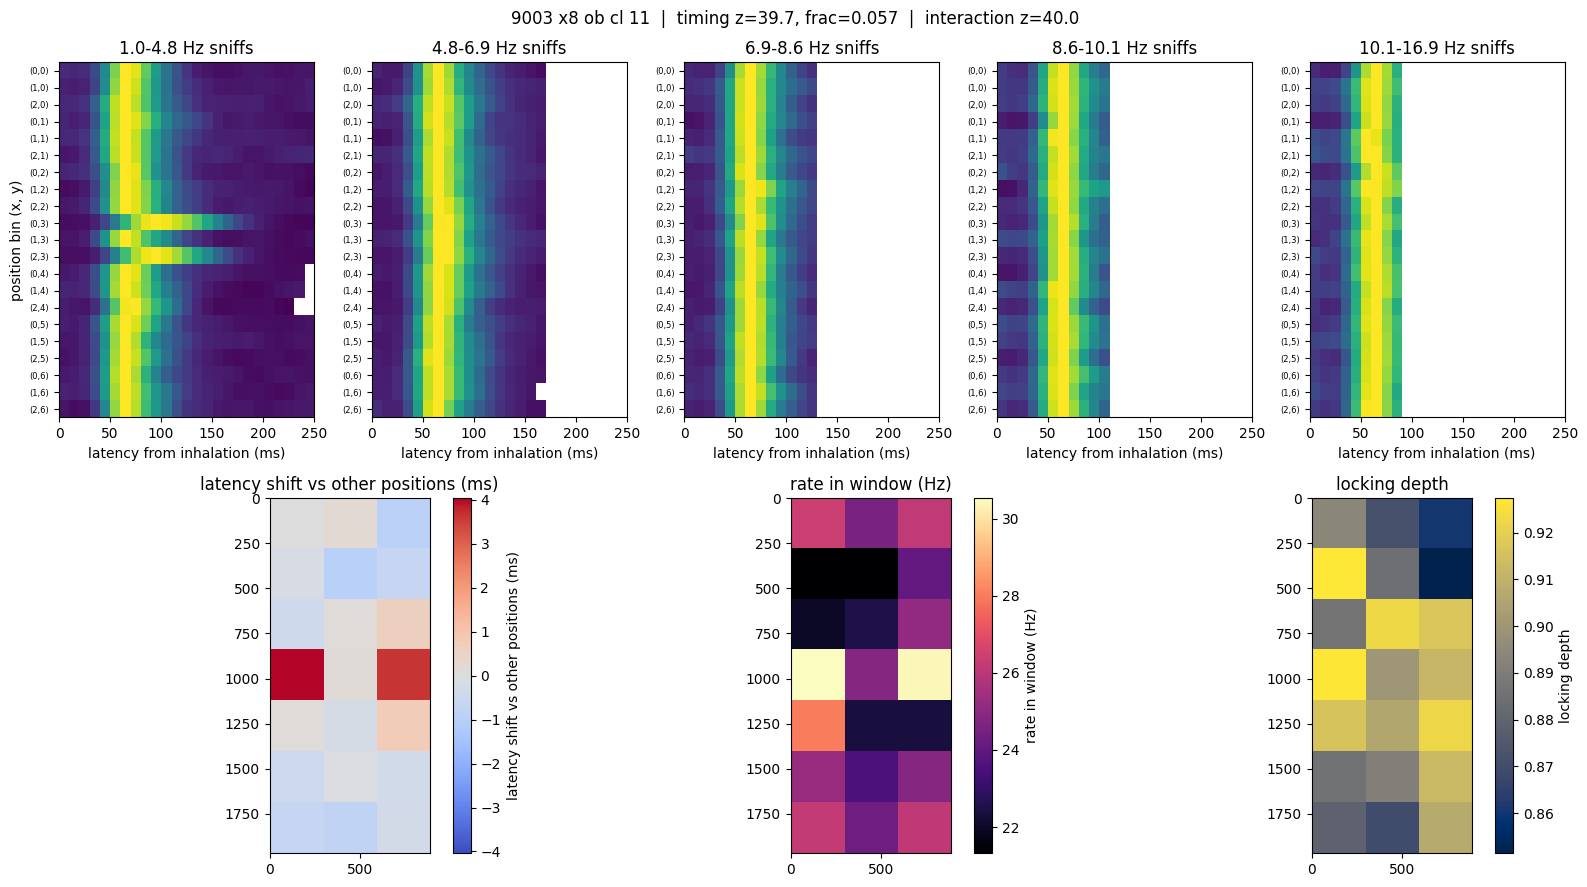

In [6]:
for _, u in top_timing.head(3).iterrows():
    plot_unit(u['mouse'], u['session'], u['cluster'])

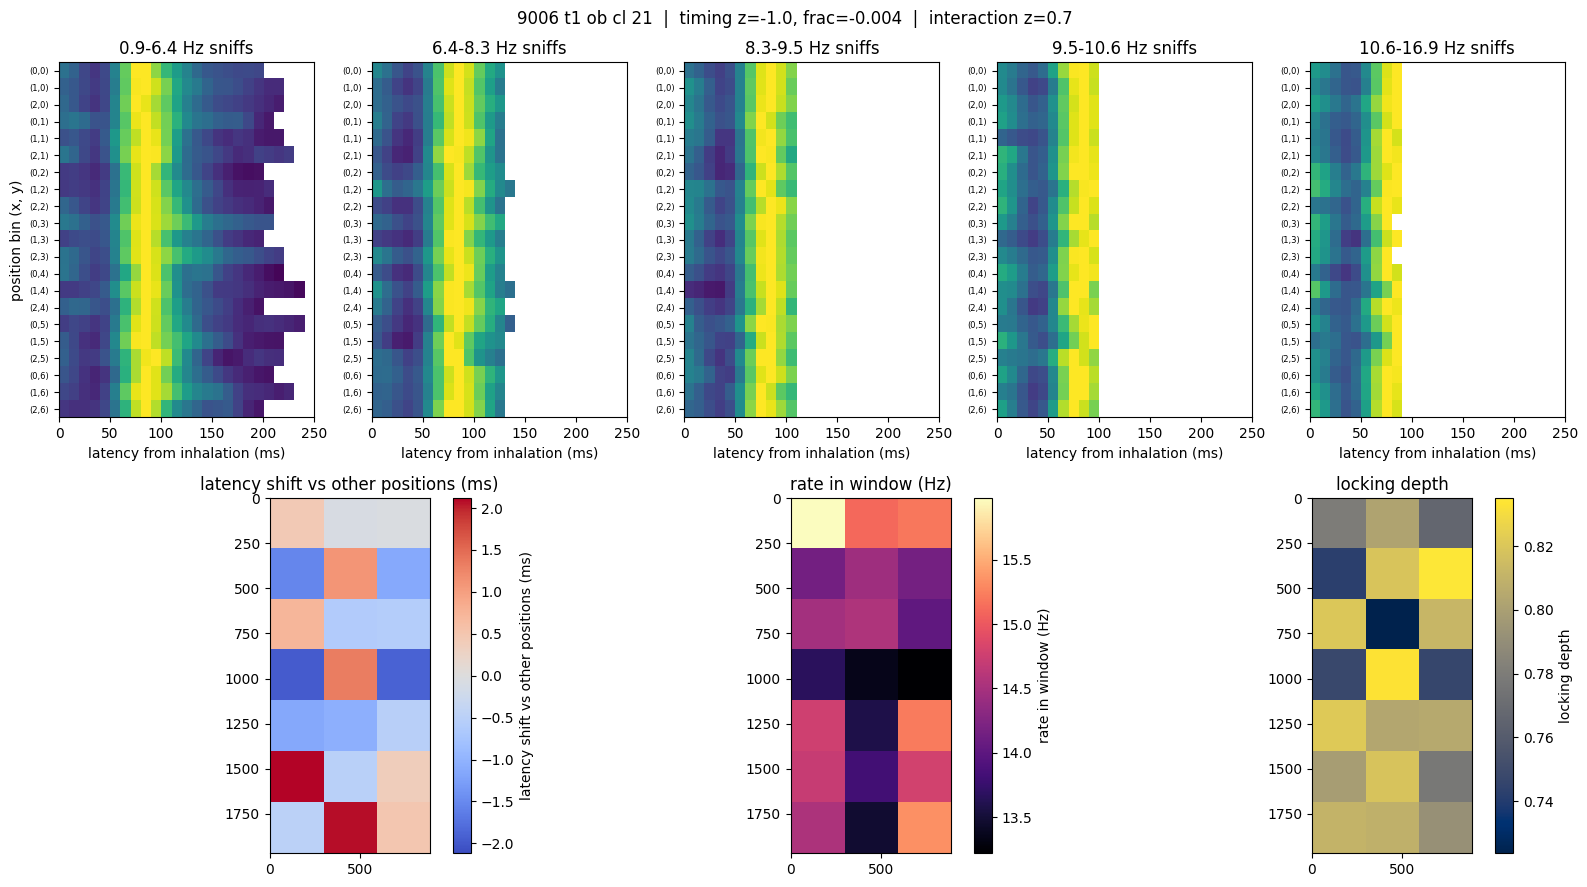

In [7]:
# a strongly sniff-locked unit whose locking does NOT depend on position, for comparison
stable = locked[(locked['info_z'] > locked['info_z'].quantile(0.9))].sort_values('interaction_z').iloc[0]
plot_unit(stable['mouse'], stable['session'], stable['cluster'])